<a href="https://colab.research.google.com/github/nakkue/deeplearning/blob/main/2%EC%A3%BC%EC%B0%A8_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

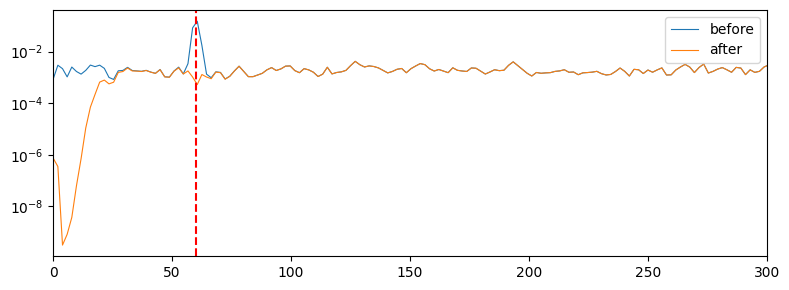

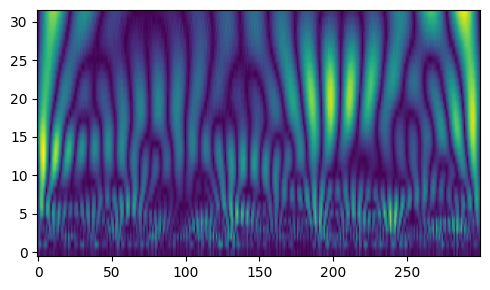

학습 데이터 변환 완료! 최종 크기: (285, 3, 32, 300)
Epoch 1/5 - Loss: 1.8175
Epoch 2/5 - Loss: 1.5481
Epoch 3/5 - Loss: 1.4778
Epoch 4/5 - Loss: 1.3897
Epoch 5/5 - Loss: 1.0748


In [1]:
# [Cell 1] 라이브러리 및 환경 설정
!pip install PyWavelets -q
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, iirnotch, filtfilt, welch
import pywt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import densenet161

FS, WIN, HOP = 1000, 300, 150
SCALES = np.arange(1, 33)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# [Cell 2] 단계 1: 필터 정의 및 전처리
def preprocess(x, fs=FS):
    bn, an = iirnotch(60, 30, fs)
    x = filtfilt(bn, an, x, axis=0)
    b, a = butter(4, [20/(fs/2), 499/(fs/2)], btype='band')
    return filtfilt(b, a, x, axis=0)

np.random.seed(42)
x_dummy = np.random.randn(3000, 2) + np.sin(2 * np.pi * 60 * np.linspace(0, 3, 3000))[:, None]
xf_dummy = preprocess(x_dummy)

# [Cell 3] 단계 2: 필터 검증 (시각화 및 저장)
f0, P0 = welch(x_dummy[:, 0], fs=FS, nperseg=512)
f1, P1 = welch(xf_dummy[:, 0], fs=FS, nperseg=512)
plt.figure(figsize=(8, 3))
plt.semilogy(f0, P0, label='before', lw=0.8)
plt.semilogy(f1, P1, label='after', lw=0.8)
plt.axvline(60, color='r', ls='--')
plt.xlim(0, 300)
plt.legend(); plt.tight_layout()
plt.savefig('filter_check.png', dpi=120)
plt.show()

# [Cell 4] 단계 3 & 4: 윈도우 분할 및 정규화
def make_windows(x, win=WIN, hop=HOP):
    n = (len(x) - win) // hop + 1
    return np.stack([x[i*hop : i*hop+win] for i in range(n)])

def minmax(w, eps=1e-8):
    mn = w.min(axis=(1,2), keepdims=True)
    mx = w.max(axis=(1,2), keepdims=True)
    return (w - mn) / (mx - mn + eps)

wn = minmax(make_windows(xf_dummy))

# [Cell 5] 단계 5: CWT 변환 및 저장
def to_cwt(one_window, wavelet='morl'):
    maps = []
    for ch in range(one_window.shape[1]):
        coef, _ = pywt.cwt(one_window[:, ch], SCALES, wavelet)
        maps.append(np.abs(coef))
    maps.append((maps[0] + maps[1]) / 2)
    return np.stack(maps).astype(np.float32)

t = to_cwt(wn[0])
plt.figure(figsize=(5, 3))
plt.imshow(t[0], aspect='auto', origin='lower')
plt.tight_layout()
plt.savefig('cwt_example.png', dpi=120)
plt.show()

# [Cell 6] 단계 6: 데이터셋 만들기 (시행 단위 분할)
# 랜덤 시드 고정 및 클래스 균등 생성
np.random.seed(42)

# 각 5개 클래스(0~4)가 4개씩 정확히 총 20개 생성되도록 보장
dummy_files = [np.random.randn(3000, 2) + np.sin(2 * np.pi * 60 * np.linspace(0, 3, 3000))[:, None] for _ in range(20)]
dummy_labels = np.repeat(np.arange(5), 4) # [0,0,0,0, 1,1,1,1, 2,2,2,2, 3,3,3,3, 4,4,4,4]

# 1) 데이터 누수 방지: 시행(file) 단위로 우선 Train/Test 분할 (test_size=0.2)
tr_files, te_files, tr_labels, te_labels = train_test_split(
    dummy_files, dummy_labels, test_size=0.25, stratify=dummy_labels, random_state=42
)

# 2) 전처리 및 CWT 텐서 변환 집계
def build_dataset(flist, llist):
    X, y = [], []
    for sig, lbl in zip(flist, llist):
        sig_p = preprocess(sig)
        for w in minmax(make_windows(sig_p)):
            X.append(to_cwt(w))
            y.append(lbl)
    return np.stack(X), np.array(y)

X_train, y_train = build_dataset(tr_files, tr_labels)
X_test, y_test = build_dataset(te_files, te_labels)

# 파이토치 데이터로더 생성
train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

print('학습 데이터 변환 완료! 최종 크기:', X_train.shape)

# [Cell 7] 단계 7: DenseNet161 학습
model = densenet161(weights=None)
model.classifier = nn.Linear(2208, 5)
model.to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

for epoch in range(5):
    model.train()
    tot_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(model(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()
        tot_loss += loss.item()
    print(f"Epoch {epoch+1}/5 - Loss: {tot_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), 'densenet161_model.pth')